In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the raw dataset

data_path = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Basic data audit

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Attrition"].value_counts())

print("\nData types:")
print(df.dtypes)

Dataset shape: (1470, 35)

Missing values:
0

Duplicate rows: 0

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Data types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating        

In [5]:
# Data cleaning

df_clean = df.copy()

# Drop identifier and constant columns
df_clean = df_clean.drop(
    columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
)

# Remove extra spaces from text columns
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip()

# Encode target
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})

print("Cleaning completed.")
print("Cleaned shape:", df_clean.shape)
print(df_clean.head())


Cleaning completed.
Cleaned shape: (1470, 31)
   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   
3   33          0  Travel_Frequently       1392  Research & Development   
4   27          0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfactio

In [7]:
# Feature engineering

df_final = df_clean.copy()

df_final["OverTime_Flag"] = df_final["OverTime"].map({"Yes": 1, "No": 0})
df_final["Gender_Flag"] = df_final["Gender"].map({"Male": 1, "Female": 0})

df_final["PromotionGap"] = (
    df_final["YearsAtCompany"] - df_final["YearsSinceLastPromotion"]
)

df_final["RoleTenureRatio"] = (
    df_final["YearsInCurrentRole"] / (df_final["YearsAtCompany"] + 1)
)

df_final["ManagerTenureRatio"] = (
    df_final["YearsWithCurrManager"] / (df_final["YearsAtCompany"] + 1)
)

df_final["IncomePerWorkingYear"] = (
    df_final["MonthlyIncome"] / (df_final["TotalWorkingYears"] + 1)
)

print("Feature engineering completed.")
print("Final shape:", df_final.shape)

Feature engineering completed.
Final shape: (1470, 37)


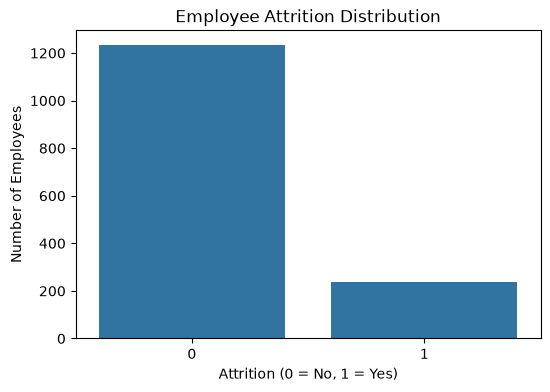

In [8]:
# Attrition distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Number of Employees")
plt.show()

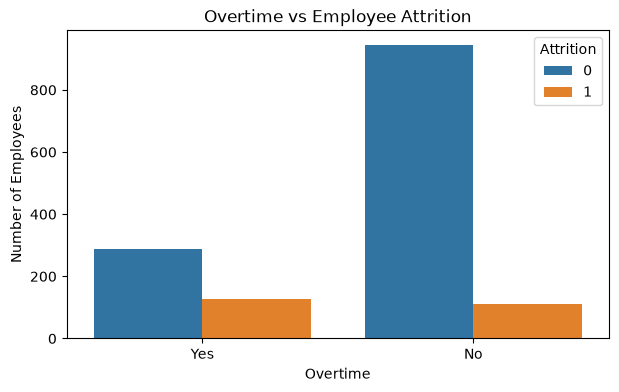

In [9]:
# Overtime vs Attrition

plt.figure(figsize=(7, 4))
sns.countplot(data=df_final, x="OverTime", hue="Attrition")
plt.title("Overtime vs Employee Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()

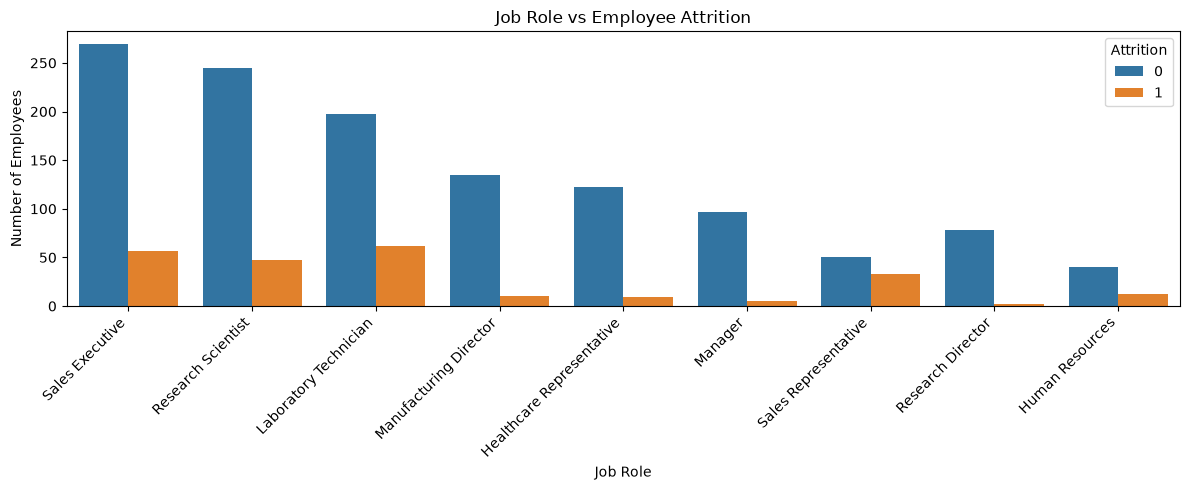

In [10]:
# Job Role vs Attrition

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_final,
    x="JobRole",
    hue="Attrition"
)
plt.title("Job Role vs Employee Attrition")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

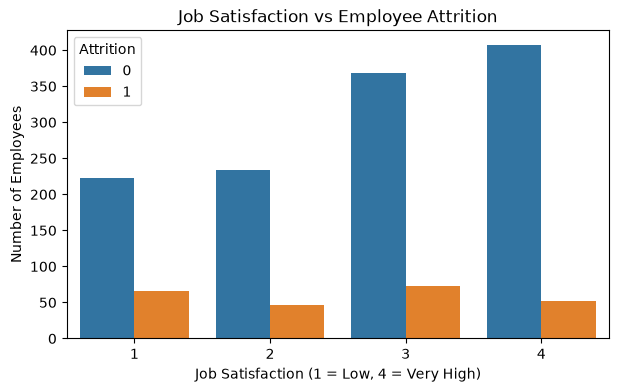

In [11]:
# Job Satisfaction vs Attrition

plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_final,
    x="JobSatisfaction",
    hue="Attrition"
)
plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction (1 = Low, 4 = Very High)")
plt.ylabel("Number of Employees")
plt.show()

In [12]:
# Prepare features and target

X = df_final.drop(columns=["Attrition"])
y = df_final["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1176
Testing samples: 294


In [13]:
# Train machine learning models

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [14]:
# Model evaluation

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7687     0.3765  0.6809    0.4848   0.8145
      Random Forest    0.8265     0.4412  0.3191    0.3704   0.7707
  Gradient Boosting    0.8469     0.5714  0.1702    0.2623   0.8082


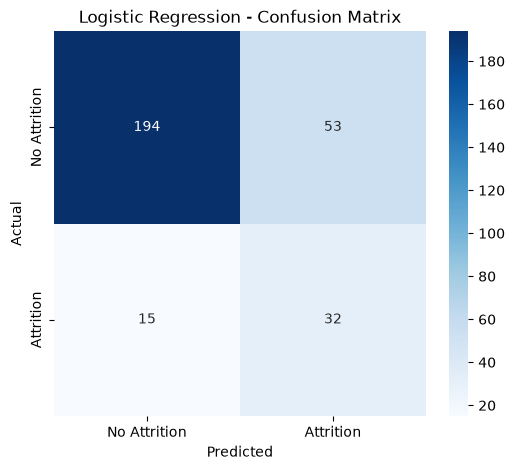

              precision    recall  f1-score   support

No Attrition       0.93      0.79      0.85       247
   Attrition       0.38      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



In [17]:
# Confusion matrix for Logistic Regression

logistic_model = trained_models["Logistic Regression"]

y_pred_logistic = logistic_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Attrition", "Attrition"]
))

In [18]:
# Display final model comparison

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7687,0.3765,0.6809,0.4848,0.8145
1,Random Forest,0.8265,0.4412,0.3191,0.3704,0.7707
2,Gradient Boosting,0.8469,0.5714,0.1702,0.2623,0.8082


## Conclusion

WorkforcePulse analyzed employee attrition patterns using the IBM HR Analytics dataset and developed three machine learning models: Logistic Regression, Random Forest, and Gradient Boosting.

The models produced different performance profiles. Logistic Regression achieved the highest recall (0.6809), F1 score (0.4848), and ROC-AUC (0.8145) among the three models, while Gradient Boosting achieved the highest accuracy (0.8469) and precision (0.5714).

These results show that model selection depends on the evaluation metric and business objective. For employee attrition analysis, recall is particularly relevant because identifying employees who may leave can be important for workforce planning.

The project demonstrates a complete machine learning workflow including data cleaning, exploratory analysis, feature engineering, preprocessing, model training, and evaluation.

### Limitations

- The dataset is relatively small and synthetic in nature.
- The target variable is imbalanced, with fewer employees belonging to the attrition class.
- The results should be interpreted as analytical findings from the provided dataset and should not be treated as a real-world HR decision system.

# WorkforcePulse — Employee Attrition Analytics & Prediction

## Project Overview

WorkforcePulse is a machine learning project that analyzes employee attrition patterns and builds predictive models to identify factors associated with employee turnover.

The project uses the IBM HR Analytics Employee Attrition & Performance dataset and covers data cleaning, exploratory data analysis, feature engineering, machine learning model training, and evaluation.